# **Mineral Prospectivity Project**
## 03 feature engineering

goals:\
-create spatial grid\
-sample data into grid

# Part 1. import packages and specify grid details

a. grid information:\
-1 km x 1 km resolution\
-extent: state of Idaho

In [116]:
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import box

data_path = "/Users/adbyerly/prospectivity_model/data/processed/"

aoi = gpd.read_file('/Users/adbyerly/prospectivity_model/data/raw/maps/idaho_outline.gpkg')
print(aoi.crs)
# print(aoi.geometry.iloc[0])
# print(aoi.total_bounds)

EPSG:4269


# Part 2. build grid

In [117]:
# create grid
aoi = aoi.to_crs("EPSG:32611")     # convert to UTM Zone 11N (not perfect, but a good compromise for all of Idaho)
print(aoi.crs)

xmin, ymin, xmax, ymax = aoi.total_bounds
cell_size = 5000
# print(aoi.geometry.iloc[0])
# print(aoi.total_bounds)


EPSG:32611


In [118]:
grid_cells = [
    box(x, y, x + cell_size, y + cell_size)
    for x in np.arange(xmin, xmax, cell_size)
    for y in np.arange(ymin, ymax, cell_size)
]

grid = gpd.GeoDataFrame(geometry=grid_cells, crs=target_crs)

grid = grid[grid.centroid.within(aoi.unary_union)]
grid["cell_id"] = range(len(grid))
# print(grid["cell_id"].is_unique)


/var/folders/5k/44z6_qv57sz8v3pzftxvfn4m0000gn/T/ipykernel_1219/1527720577.py:9: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  grid = grid[grid.centroid.within(aoi.unary_union)]


Are the cell IDs all unique?: True
EPSG:32611
There are 8706 cells in the grid.
The x cell dimensions are 5000.0 meters.
The y cell dimensions are 5000.0 meters.


<Axes: >

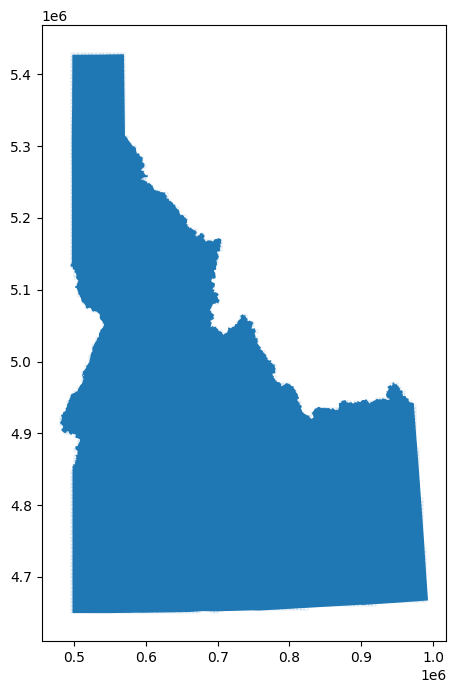

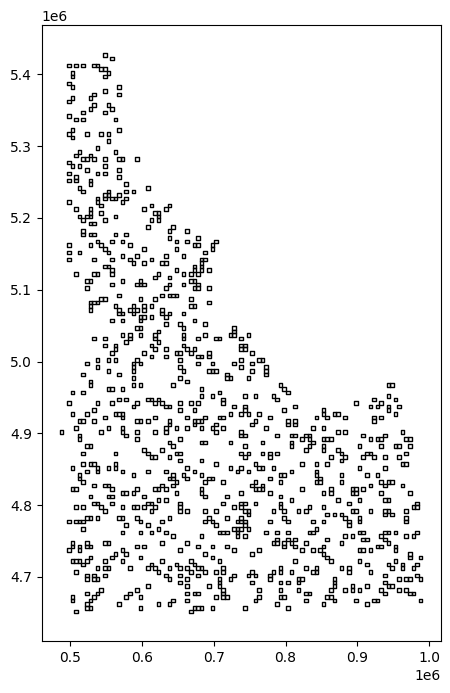

In [119]:
# grid QC
print('Are the cell IDs all unique?: ' + str(grid["cell_id"].is_unique))
print(grid.crs)
print('There are ' + str(len(grid)) + ' cells in the grid.')
cell = grid.geometry.iloc[0]

# check cell dimensions
# print(cell.bounds)
minx, miny, maxx, maxy = cell.bounds
print('The x cell dimensions are '+ str(maxx - minx) + ' meters.')
print('The y cell dimensions are ' + str(maxy - miny) + ' meters.')

# state-wide grid is too fine to see
ax = aoi.plot(figsize=(8, 8))
grid.boundary.plot(ax=ax, linewidth=0.1)

# plot a random subset of cells
grid.sample(1000).plot(
    facecolor="none",
    edgecolor="black",
    figsize=(8, 8))

# print(grid.head())
# print(grid.columns)

# Part 3. sample data into grid

In [120]:
# load target - known producing gold mines
mines_gdf_processed_producer = gpd.read_file(
    '/Users/adbyerly/prospectivity_model/data/processed/mines_gdf_processed_producer.geojson')

print(mines_gdf_processed_producer.head())
print(mines_gdf_processed_producer.crs)

    IGSID                                           NameList  \
0  BA0006                                  North Hornet Mine   
1  BA0015  Cuddy Mine, Freeze Prospect, Cuddy Mountain Mi...   
2  BA0017  Keystone, Galena, Lead Zone Mine, Salena, Gale...   
3  BA0018         Edna May Prospect, Snowslide, Mundee Mines   
4  BA0032                    Railroad Mine, Held Mine, Heald   

                                          CommodityL  \
0  uranium, gold, tantalum, niobium, abrasives, c...   
1                         silver, gold, copper, iron   
2                   lead, silver, zinc, copper, gold   
3                   silver, gold, copper, zinc, lead   
4                      gold, silver, bismuth, copper   

                                          CompanyLis    NAD27lon   NAD27lat  \
0                                                NaN -116.638173  44.890766   
1               Aries Resources, Cuddy Mountain Gold -116.732617  44.810767   
2  Lead Zone Mining, Mundee Mines, Anglo-

In [121]:
# join mine locations with grid; resulting dataframe will be mine data with cell id added as a column
mine_cells = gpd.sjoin(mines_gdf_processed_producer, 
                       grid[['cell_id', 'geometry']],
                       predicate = 'within', 
                       how = 'left')

grid['gold'] = (grid['cell_id'].isin(mine_cells['cell_id']).astype(int))
print(grid["gold"].value_counts())
# print(mine_cells.head())
print(grid.head())

gold
0    7917
1     789
Name: count, dtype: int64
                                              geometry  cell_id  gold
52   POLYGON ((485643.93 4909552.881, 485643.93 491...        0     0
53   POLYGON ((485643.93 4914552.881, 485643.93 491...        1     0
54   POLYGON ((485643.93 4919552.881, 485643.93 492...        2     0
206  POLYGON ((490643.93 4899552.881, 490643.93 490...        3     0
207  POLYGON ((490643.93 4904552.881, 490643.93 490...        4     0


<Axes: >

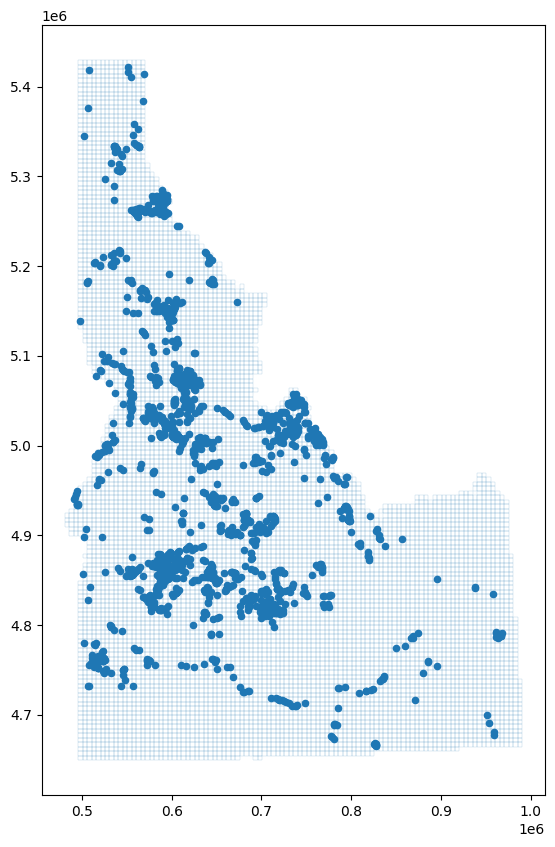

In [122]:
ax = grid.boundary.plot(figsize=(10,10), linewidth=0.1)

mines_gdf_processed_producer.plot(ax=ax,markersize=20)

In [123]:
# assign cell IDs to NGDB NAA geochemical data
ngdb_naa_pathfinders = gpd.read_file(data_path + "/NGDB/ngdb_naa_pathfinders.geojson")
# print(ngdb_naa_pathfinders.head())
# print(ngdb_naa_pathfinders.crs)

ngdb_naa_pathfinders_cells = gpd.sjoin(ngdb_naa_pathfinders,
                     grid[['cell_id', 'geometry']],
                     predicate = 'within',
                     how = 'left')

print(ngdb_naa_pathfinders_cells.head())

    lab_id  auppb_na cuppm_na hgppm_na  coppm_na  sbppm_na  asppm_na  \
0  C176401       NaN     None     None     0.350    0.0629     0.527   
1  C176402       NaN     None     None    17.400    0.0271     0.246   
2  C176403       0.1     None     None    17.200    0.0464     0.642   
3  C176411       0.1     None     None     0.476    0.0677     0.227   
4  C176412       NaN     None     None     8.610    0.0733     0.267   

   znppm_na                        geometry  index_right  cell_id  
0      10.8   POINT (549643.39 4966000.348)       2091.0   1469.0  
1      72.0  POINT (549754.439 4965846.793)       2091.0   1469.0  
2      92.8  POINT (549754.439 4965846.793)       2091.0   1469.0  
3      36.3  POINT (588531.423 4959290.827)       3337.0   2641.0  
4      84.4  POINT (583978.986 4959476.391)       3181.0   2511.0  


In [124]:
# aggregate NGDB NAA geochemical data by cell
# start by creating dataframe with aggregate max values for each pathfinder element

ngdb_naa_pathfinders_grid = (ngdb_naa_pathfinders_cells.groupby('cell_id').agg({
        'auppb_na' : 'max',
        'cuppm_na' : 'max',
        'hgppm_na' : 'max',
        'coppm_na' : 'max',
        'sbppm_na' : 'max',
        'asppm_na' : 'max',
        'znppm_na' : 'max',
        'lab_id' : 'count'}).rename(columns={'lab_id' : 'sample_count'}))

print(ngdb_naa_pathfinders_grid.head())

         auppb_na cuppm_na hgppm_na  coppm_na  sbppm_na  asppm_na  znppm_na  \
cell_id                                                                       
70.0          NaN      NaN      NaN     42.80       NaN       NaN     116.0   
81.0          NaN      NaN      NaN     30.00      1.99       NaN     225.0   
111.0         4.0      NaN      NaN      1.54      0.07       0.5      23.4   
137.0         3.0      NaN      NaN      0.55      0.42       4.4      59.8   
141.0         4.0      NaN      NaN      0.34      0.25       2.1      61.2   

         sample_count  
cell_id                
70.0                1  
81.0                1  
111.0               2  
137.0               2  
141.0               2  


In [125]:
#  join of geochemical data with grid

grid = grid.merge(ngdb_naa_pathfinders_grid, on = 'cell_id', how = 'left')

                                            geometry  cell_id  gold  auppb_na  \
0  POLYGON ((485643.93 4909552.881, 485643.93 491...        0     0       NaN   
1  POLYGON ((485643.93 4914552.881, 485643.93 491...        1     0       NaN   
2  POLYGON ((485643.93 4919552.881, 485643.93 492...        2     0       NaN   
3  POLYGON ((490643.93 4899552.881, 490643.93 490...        3     0       NaN   
4  POLYGON ((490643.93 4904552.881, 490643.93 490...        4     0       NaN   

  cuppm_na hgppm_na  coppm_na  sbppm_na  asppm_na  znppm_na  sample_count  
0      NaN      NaN       NaN       NaN       NaN       NaN           NaN  
1      NaN      NaN       NaN       NaN       NaN       NaN           NaN  
2      NaN      NaN       NaN       NaN       NaN       NaN           NaN  
3      NaN      NaN       NaN       NaN       NaN       NaN           NaN  
4      NaN      NaN       NaN       NaN       NaN       NaN           NaN  


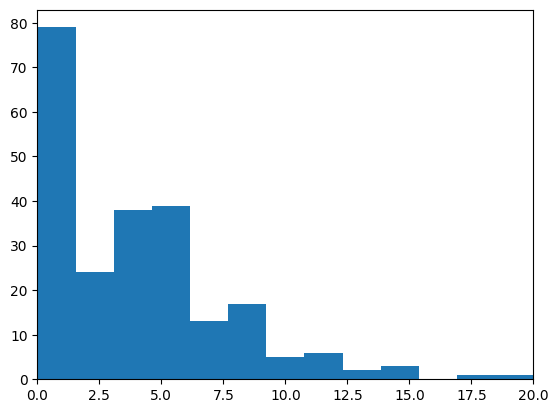

In [126]:
# check gold data to make sure geochemical sampling and aggregation workflow succeeded
print(grid.head())
au = grid['auppb_na']
plt.hist(au, range = (0,20), bins='auto')
plt.xlim(0, 20)
plt.show()

# Part 4. export data

In [127]:
# save NGDB NAA data
grid.to_file(data_path + 'grid.geojson', driver = 'GeoJSON')